# Pneumonia Detection from Chest X-Ray Images Using Deep Learning

**Author:** Ashim Singh Thapa  
**Task:** Binary image classification: `NORMAL` vs `PNEUMONIA`

Project code requirements:

1. Load the dataset
2. Transform/preprocess image data
3. Define a baseline model
4. Define a proposed deep learning model
5. Train both models on the training set
6. Evaluate both models on a withheld test set
7. Display/visualize test-set results for both models


In [7]:
# Install dependencies if needed
import sys, subprocess
packages = ["kagglehub", "tensorflow", "scikit-learn", "matplotlib", "numpy", "pandas"]
for package in packages:
    try:
        __import__(package if package != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

In [8]:
# Import libraries
import os
import random
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: False


## 1. Load the dataset

The dataset is downloaded from Kaggle using `kagglehub`. The folder should contain `train`, `val`, and `test` directories with `NORMAL` and `PNEUMONIA` subfolders.

In [9]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset downloaded to:", path)

base_path = Path(path)
possible_dirs = list(base_path.rglob("chest_xray"))
data_dir = possible_dirs[0] if possible_dirs else base_path

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

for split_dir in [train_dir, val_dir, test_dir]:
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing expected folder: {split_dir}")

print("Data directory:", data_dir)
print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Data directory: /kaggle/input/chest-xray-pneumonia/chest_xray
Train directory: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validation directory: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Test directory: /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [10]:
# Count images by split and class
for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    print(f"{split_name} split")
    total = 0
    for class_name in sorted([p.name for p in split_dir.iterdir() if p.is_dir()]):
        count = len([f for f in (split_dir / class_name).glob("*") if f.is_file()])
        total += count
        print(f"  {class_name}: {count}")
    print(f"  Total: {total}")

Train split
  NORMAL: 1341
  PNEUMONIA: 3875
  Total: 5216
Validation split
  NORMAL: 8
  PNEUMONIA: 8
  Total: 16
Test split
  NORMAL: 234
  PNEUMONIA: 390
  Total: 624


## 2. Transform/preprocess image data

Images are resized to `150 x 150`, batched, and normalized inside the models using `Rescaling(1./255)`. The proposed CNN also includes data augmentation.

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels="inferred", label_mode="binary", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels="inferred", label_mode="binary", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels="inferred", label_mode="binary", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)
print("Class index meaning:", {i: name for i, name in enumerate(class_names)})

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']
Class index meaning: {0: 'NORMAL', 1: 'PNEUMONIA'}


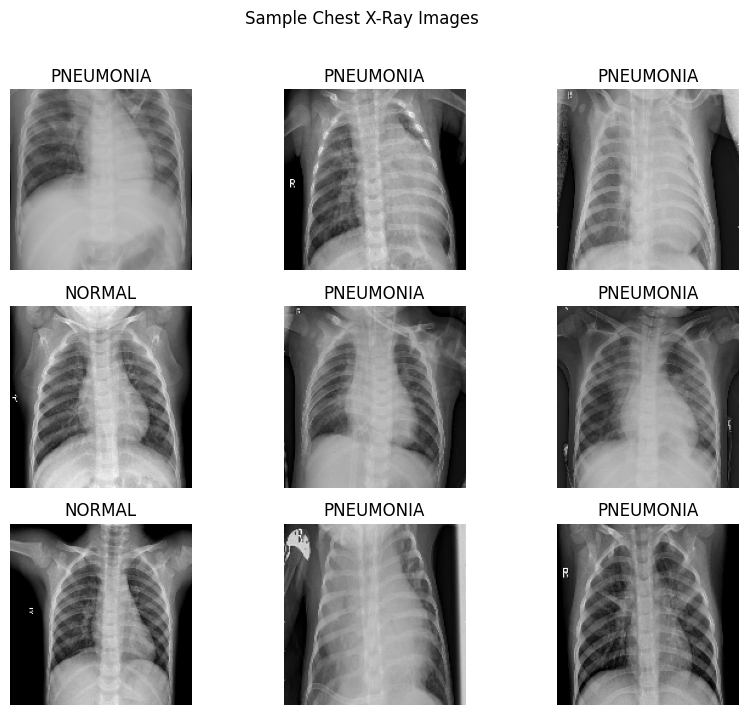

In [12]:
# Display sample training images
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_id = int(labels[i].numpy()[0])
        plt.title(class_names[label_id])
        plt.axis("off")
plt.suptitle("Sample Chest X-Ray Images")
plt.show()

## 3. Helper functions

The same training/evaluation workflow is used for both the baseline model and the proposed CNN model.

In [15]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model


def plot_history(history, title):
    hist = history.history

    plt.figure(figsize=(7,5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def get_true_and_pred(model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)

        y_prob.extend(probs)
        y_true.extend(labels.numpy().reshape(-1))

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    return y_true, y_pred, y_prob


def evaluate_model(model, dataset, model_name):

    y_true, y_pred, y_prob = get_true_and_pred(model, dataset)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
    }

    print(f"\nClassification Report: {model_name}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0,1], class_names)
    plt.yticks([0,1], class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                cm[i,j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.show()

    return metrics, y_true, y_pred, y_prob

## 4. Baseline model

The baseline model is a very simple learned model: resize/rescale → flatten pixels → one dense sigmoid output layer.

In [16]:
baseline_model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
], name="Baseline_Flatten_Dense")

baseline_model = compile_model(baseline_model)
baseline_model.summary()

Model: "Baseline_Flatten_Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        67,501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,501 (263.68 KB)

 Trainable params: 67,501 (263.68 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Proposed CNN model

The proposed CNN learns spatial image features using convolutional layers, max pooling, dropout, and dense layers.

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
], name="data_augmentation")

cnn_model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="Proposed_CNN")

cnn_model = compile_model(cnn_model)
cnn_model.summary()

Model: "Proposed_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,042,881 (11.61 MB)

 Trainable params: 3,042,881 (11.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train both models

Both models are trained on the training set. The validation set is used only for monitoring during training. The test set remains withheld until final evaluation.

In [18]:
EPOCHS_BASELINE = 5
EPOCHS_CNN = 8
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

print("Training baseline model...")
baseline_history = baseline_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_BASELINE, callbacks=callbacks)

Training baseline model...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.8553 - loss: 0.6069 - precision: 0.9002 - recall: 0.9055 - val_accuracy: 0.6250 - val_loss: 0.9855 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9199 - loss: 0.2468 - precision: 0.9445 - recall: 0.9479 - val_accuracy: 0.6250 - val_loss: 1.0793 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9268 - loss: 0.2585 - precision: 0.9507 - recall: 0.9507 - val_accuracy: 0.5625 - val_loss: 1.6182 - val_precision: 0.5333 - val_recall: 1.0000
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9340 - loss: 0.2474 - precision: 0.9556 - recall: 0.9556 - val_accuracy: 0.5625 - val_loss: 2.0015 - val_precision: 0.5333 - val_recall: 1.0000


In [19]:
print("Training proposed CNN model...")
cnn_history = cnn_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CNN, callbacks=callbacks)

Training proposed CNN model...
Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.7395 - loss: 0.5617 - precision: 0.7520 - recall: 0.9688 - val_accuracy: 0.6250 - val_loss: 0.7342 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.7922 - loss: 0.4169 - precision: 0.8118 - recall: 0.9375 - val_accuracy: 0.8125 - val_loss: 0.4743 - val_precision: 0.7273 - val_recall: 1.0000
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.8867 - loss: 0.2668 - precision: 0.9048 - recall: 0.9471 - val_accuracy: 0.8125 - val_loss: 0.5430 - val_precision: 0.7273 - val_recall: 1.0000
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9137 - loss: 0.2062 - precision: 0.9319 - recall: 0.9535 - val_accuracy: 0.7500 - val_loss: 0.9945 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9346 - loss: 0.1760 - precision: 0.9535 - recall: 0.9587 - val_

## 7. Visualize training results

The plots below show training/validation accuracy and loss for both models.

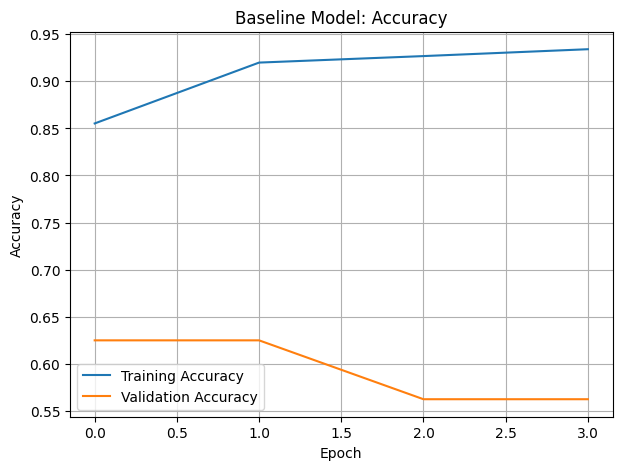

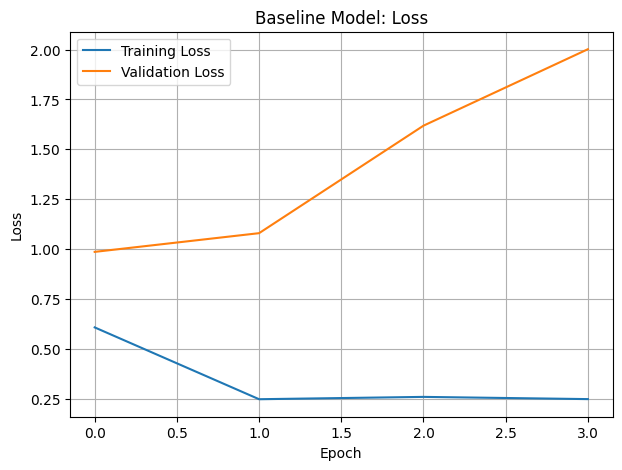

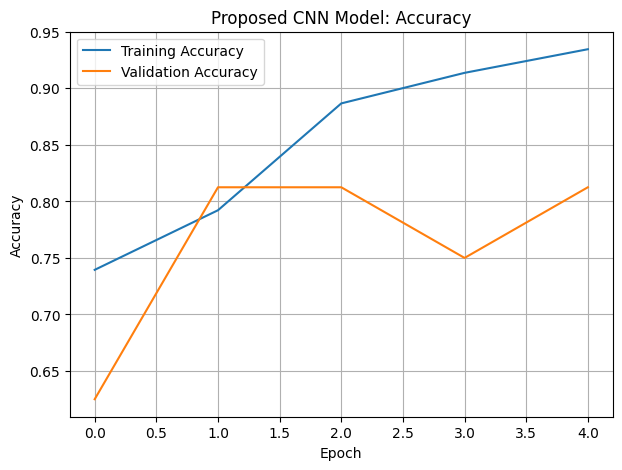

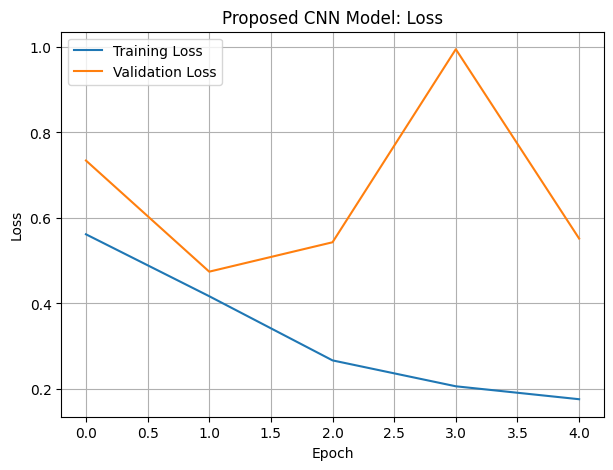

In [20]:
plot_history(baseline_history, "Baseline Model")
plot_history(cnn_history, "Proposed CNN Model")

## 8. Evaluate both models on the withheld test set

The final evaluation reports accuracy, precision, recall, and F1-score for both models.


Classification Report: Baseline Flatten + Dense
              precision    recall  f1-score   support

      NORMAL       0.98      0.20      0.33       234
   PNEUMONIA       0.67      1.00      0.80       390

    accuracy                           0.70       624
   macro avg       0.83      0.60      0.57       624
weighted avg       0.79      0.70      0.63       624



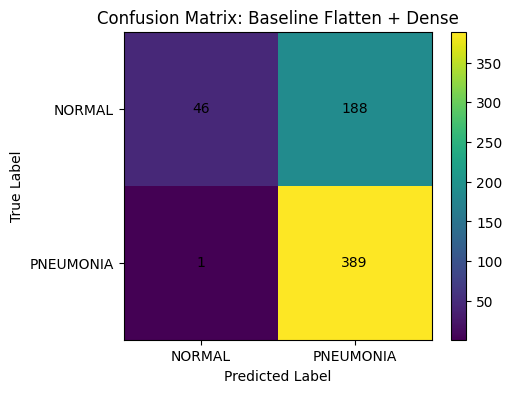


Classification Report: Proposed CNN
              precision    recall  f1-score   support

      NORMAL       0.85      0.74      0.79       234
   PNEUMONIA       0.86      0.92      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.83      0.84       624
weighted avg       0.86      0.86      0.85       624



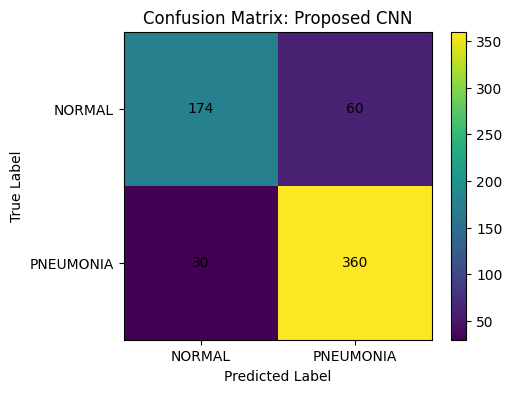

In [21]:
baseline_metrics, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(baseline_model, test_ds, "Baseline Flatten + Dense")
cnn_metrics, cnn_y_true, cnn_y_pred, cnn_y_prob = evaluate_model(cnn_model, test_ds, "Proposed CNN")

In [22]:
results_df = pd.DataFrame([baseline_metrics, cnn_metrics])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Flatten + Dense,0.697115,0.674177,0.997436,0.804550
1,Proposed CNN,0.855769,0.857143,0.923077,0.888889


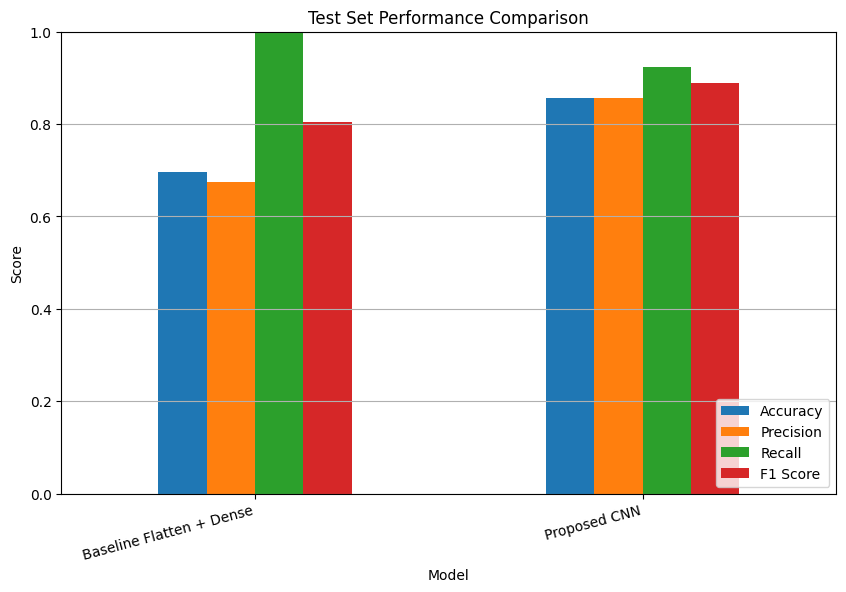

In [23]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]
results_df.set_index("Model")[metric_columns].plot(kind="bar", figsize=(10, 6))
plt.title("Test Set Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

## 9. Display example predictions from the proposed CNN model

This section displays test images with true labels, predicted labels, and confidence scores.

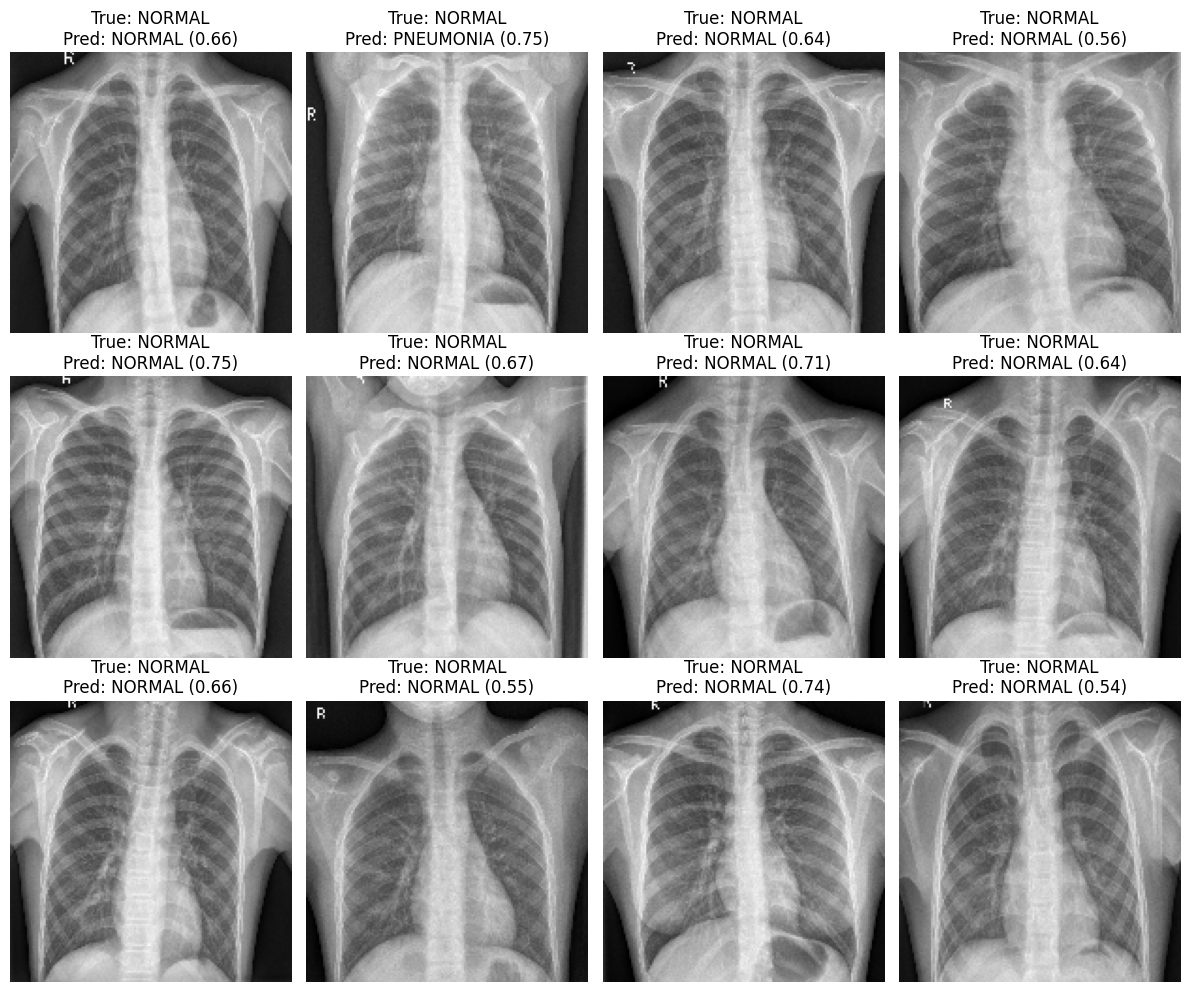

In [25]:
plt.figure(figsize=(12,10))

shown = 0

for images, labels in test_ds.take(2):

    probs = cnn_model.predict(images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)

    for i in range(images.shape[0]):

        if shown >= 12:
            break

        plt.subplot(3,4,shown+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[int(labels[i].numpy()[0])]
        pred_label = class_names[int(preds[i])]

        confidence = probs[i] if preds[i] == 1 else 1-probs[i]

        plt.title(
            f"True: {true_label}\n"
            f"Pred: {pred_label} ({confidence:.2f})"
        )

        plt.axis("off")

        shown += 1

    if shown >= 12:
        break

plt.tight_layout()
plt.show()

## 10. Conclusion

This notebook compared a simple baseline model with a proposed CNN model for pneumonia detection from chest X-ray images. The final table and bar chart show how both models performed on the withheld test set. In a medical classification task like pneumonia detection, recall is especially important because missing a pneumonia case can be dangerous.
